In [1]:
%cd ..
%load_ext autoreload
%autoreload 2

/Users/admin/repos/geneforge


/Users/admin/repos/geneforge/venv/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
# Configure logger to ignore everything to avoid cluttering the output
import logging
logging.getLogger().setLevel(logging.WARNING)

In [3]:
import json
from src.examples.agent.design_w_promoter_vars import DesignWithPromoterVarsRunner


def generate_chat_histories(output_dir, num_attempts, start_index=0):
    from src.examples.agent.design_w_promoter_vars import run_example
    import json, os
    for attempt_index in range(start_index, start_index + num_attempts):
        runner = run_example()

        messages = runner.messages
        
        run_id = f"design_w_promoter_vars_dataset_{attempt_index}"
        os.makedirs(f"outputs/chat_histories/{runner.model}/{run_id}", exist_ok=True)
        with open(f"outputs/chat_histories/{runner.model}/{run_id}/chat_history.json", "w") as f:
            json.dump(messages, f)
        with open(f"outputs/chat_histories/{runner.model}/{run_id}/session_state.json", "w") as f:
            json.dump(runner.session_state_history().to_dict(), f)

def get_scores_for_runs(directory):
    from glob import glob
    scores = {}
    for chat_history_file in glob(f"{directory}/*/chat_history.json"):
        with open(chat_history_file, "r") as f:
            messages = json.load(f)
        with open(chat_history_file.replace("chat_history.json", "session_state.json"), "r") as f:
            session_state = json.load(f)
        score = DesignWithPromoterVarsRunner.score_run(messages, session_state['history'])
        scores[chat_history_file] = score
    return scores

In [ ]:
%%capture

generate_chat_histories(output_dir="outputs/chat_histories", num_attempts=100, start_index=0)

In [ ]:
scores = get_scores_for_runs("outputs/chat_histories/gpt-4.1-2025-04-14")

Mean score: 0.12097916666666668
Std score: 0.14622514478963594
Min score: -0.0375
Max score: 0.5645833333333333
Average number of messages: 18.53
Average number of tool calls: 4.12
Average number of tool failures: 0.53


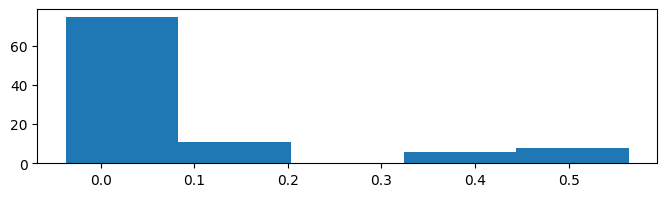

In [9]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
# Here are the values we hope to improve after training

score_values = [scores[k]['score'] for k in scores.keys()]
print(f"Mean score: {np.mean(score_values)}")
print(f"Std score: {np.std(score_values)}")
print(f"Min score: {np.min(score_values)}")
print(f"Max score: {np.max(score_values)}")

num_tool_calls = sum([scores[k]['num_tool_calls'] for k in scores.keys()])
num_messages = sum([scores[k]['num_messages'] for k in scores.keys()])
num_tool_failures = sum([scores[k]['num_tool_failures'] for k in scores.keys()])

print(f"Average number of messages: {num_messages / len(scores.keys())}")
print(f"Average number of tool calls: {num_tool_calls / len(scores.keys())}")
print(f"Average number of tool failures: {num_tool_failures / len(scores.keys())}")

# # show distribution of scores
plt.figure(figsize=(8, 2))
plt.hist(score_values, bins=5)
plt.show()
# show distribution of num_tool_failures

In [10]:
sorted_scores = sorted(scores.keys(), key=lambda x: scores[x]['score'])

print('Best score: ', sorted_scores[0], scores[sorted_scores[0]]['score'])
print('Worst score: ', sorted_scores[-1], scores[sorted_scores[-1]]['score'])

Best score:  outputs/chat_histories/gpt-4.1-2025-04-14/design_w_promoter_vars_dataset_0/chat_history.json -0.0375
Worst score:  outputs/chat_histories/gpt-4.1-2025-04-14/design_w_promoter_vars_dataset_83/chat_history.json 0.5645833333333333


In [11]:
desired_num_pairs = 15 # 10 best and 10 worst 

# sample from the first and back, creating a good-bad pair
num_pairs = desired_num_pairs if len(sorted_scores) > desired_num_pairs else len(sorted_scores) // 2
good_bad_pairs = []
for i in range(num_pairs) :
    good_history = sorted_scores[i] # good
    bad_history = sorted_scores[len(sorted_scores) - i - 1]
    good_bad_pairs.append((good_history, bad_history))
print(good_bad_pairs)

[('outputs/chat_histories/gpt-4.1-2025-04-14/design_w_promoter_vars_dataset_0/chat_history.json', 'outputs/chat_histories/gpt-4.1-2025-04-14/design_w_promoter_vars_dataset_83/chat_history.json'), ('outputs/chat_histories/gpt-4.1-2025-04-14/design_w_promoter_vars_dataset_4/chat_history.json', 'outputs/chat_histories/gpt-4.1-2025-04-14/design_w_promoter_vars_dataset_89/chat_history.json'), ('outputs/chat_histories/gpt-4.1-2025-04-14/design_w_promoter_vars_dataset_44/chat_history.json', 'outputs/chat_histories/gpt-4.1-2025-04-14/design_w_promoter_vars_dataset_82/chat_history.json'), ('outputs/chat_histories/gpt-4.1-2025-04-14/design_w_promoter_vars_dataset_1/chat_history.json', 'outputs/chat_histories/gpt-4.1-2025-04-14/design_w_promoter_vars_dataset_77/chat_history.json'), ('outputs/chat_histories/gpt-4.1-2025-04-14/design_w_promoter_vars_dataset_35/chat_history.json', 'outputs/chat_histories/gpt-4.1-2025-04-14/design_w_promoter_vars_dataset_99/chat_history.json'), ('outputs/chat_histori

# Run preference optimization training

1. Grab a trainable llama model
2. set up the training loop 
3. run the training loop

In [20]:
# https://platform.openai.com/docs/guides/direct-preference-optimization
# The data should be formatted in JSONL format, with each line representing an example in the following structure:

# {
#   "input": {
#     "messages": [
#       {
#         "role": "user",
#         "content": "Hello, can you tell me how cold San Francisco is today?"
#       }
#     ],
#     "tools": [],
#     "parallel_tool_calls": true
#   },
#   "preferred_output": [
#     {
#       "role": "assistant",
#       "content": "Today in San Francisco, it is not quite cold as expected. Morning clouds will give away to sunshine, with a high near 68°F (20°C) and a low around 57°F (14°C)."
#     }
#   ],
#   "non_preferred_output": [
#     {
#       "role": "assistant",
#       "content": "It is not particularly cold in San Francisco today."
#     }
#   ]
# }
from src.tool_registry import tool_functions
def get_assistant_messages(messages):
    messages = [message for message in messages if message['role'] == 'assistant']
    for message in messages:
        # tool call 
        if 'tool_calls' in message:
            tool_calls = message['tool_calls']
            for tool_call in tool_calls:
                arguments = tool_call.get('function', {}).get('arguments', {})
                tool_call['function']['arguments'] = json.loads(arguments)
    return messages

def get_user_and_system_messages(messages):
    user_messages = [message for message in messages if message['role'] == 'user']
    # for message in user_messages:
        # message['tools'] = tool_functions
        # message['parallel_tool_calls'] = True
    system_messages = [message for message in messages if message['role'] == 'system']
    return system_messages + user_messages

input_messages = None
samples = []



for good, bad in good_bad_pairs:
    with open(good, "r") as f:
        good_messages = json.load(f)
        
        if input_messages is None:
            input_messages = get_user_and_system_messages(good_messages)
        
        good_response_messages = get_assistant_messages(good_messages)
        
    with open(bad, "r") as f:
        bad_messages = json.load(f)
        bad_response_messages = get_assistant_messages(bad_messages)

    sample = {"input":
                {"messages": input_messages}, 
              "preferred_output": good_response_messages, 
              "non_preferred_output": bad_response_messages}
    
    samples.append(sample)
    
    
dpo_training_set_path = "outputs/training_sets/promoter_var_dataset_gpt-4.1-2025-04-14.jsonl"
with open(dpo_training_set_path, "w") as f:
    for sample in samples:
        f.write(json.dumps(sample) + "\n")

In [21]:
from openai import OpenAI
import dotenv  
import os   

dotenv.load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key=OPENAI_API_KEY)

# upload the training set to the cloud
uploaded_file = client.files.create(
    file=open(dpo_training_set_path, "rb"),
    purpose="fine-tune",
)

job = client.fine_tuning.jobs.create(
    training_file=uploaded_file.id,
    model="gpt-4.1-2025-04-14",
    method={
        "type": "dpo",
        "dpo": {
            "hyperparameters": {"beta": 0.1},
        },
    },
)

print(job)

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/files "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/fine_tuning/jobs "HTTP/1.1 200 OK"


FineTuningJob(id='ftjob-YwjT6oU0NtkHnLxq6XBhIfhE', created_at=1751765100, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=None, model='gpt-4.1-2025-04-14', object='fine_tuning.job', organization_id='org-of1jCJNRNRU8KrBdhW7SAuzY', result_files=[], seed=1552354051, status='validating_files', trained_tokens=None, training_file='file-2r6RMqLL14UWf5D5ynbGKz', validation_file=None, estimated_finish=None, integrations=[], metadata=None, method=Method(type='dpo', dpo=DpoMethod(hyperparameters=DpoHyperparameters(batch_size='auto', beta=0.1, learning_rate_multiplier='auto', n_epochs='auto')), reinforcement=None, supervised=None), user_provided_suffix=None, usage_metrics=None, shared_with_openai=False, eval_id=None)
